#Application du TFT

## Mise en place de l'environnement

###Installation des modules

In [ ]:
!pip install pytorch-lightning pytorch-forecasting -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.8/399.8 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 39.3 MB/s eta 0:00:00


In [ ]:
# Installation des bibliothèques principales du projet
!pip install pytorch-forecasting lightning -q

# On réinstalle aussi Optuna (le robot chercheur) au cas où la session a été totalement vidée
!pip install optuna statsmodels optuna-integration -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 5.4 MB/s eta 0:00:00


###Importation des modules

In [ ]:
import copy
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
#import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger
import torch

from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

from pickle import *
import lightning.pytorch as pl
#Pour éviter un bug :
#import tensorflow as tf
#import tensorboard as tb
#tf.io.gfile = tb.compat.tensorflow_stub.io.gfile
import yfinance as yf
import pandas as pd
import numpy as np

## Manipulation des données

###Chargement des données et Feature Ingeneering

In [ ]:


# Télécharger les données de l'action Apple (symbole "AAPL")
data = yf.download("AAPL", start="2011-01-01", end="2019-01-01")
#
# On supprime le deuxième niveau de nommage des colonnes (le symbole "AAPL")
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)
print(data)

########################
print('='*50)
print('Feature Ingeneering')
print('='*50)
#######################
data = data.reset_index()
# add time index
data["time_idx"] = data.index

# add additional features
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
data["cat_month"] = data["Date"].dt.month.astype(str).astype("category")
data["cat_year"] = data["Date"].dt.year.astype(str).astype("category")
data["cat_day"] = data["Date"].dt.day.astype(str).astype("category")

data["year_code"] = (data.cat_year.astype(int) - data.cat_year.astype(int).min())
data["cat_year_code"] = data.year_code.astype("category")
data["month_temporal_code"] = (data.cat_month.astype(int) + data.year_code * 12)
data["cat_month_temporal_code"] = data.month_temporal_code.astype("category")

data["log_open"] = np.log(data.Open + 1e-8)
data["close_open"] = data.Close - data.Open ## Ici, on calcule la différence entre le prix à la fin de la journée et le prix au début.
                                            ##Ça permet de savoir de combien l'action a monté ou baissé pendant la journée.

data["day_up"] = np.where(data.close_open > 0, 1, 0) ## donne 1 si l'action en fin de journée est supérieure à celle du matin(ouverture). 0 sinon
data["cat_day_up"] = data.day_up.astype(str).astype("category")
data["last_was_day_up"] = np.where(data.close_open.shift(1) > 0, 1, 0) ## Décale la colonne close_open de 1 et affiche 1 si l'action en fin de journée est supérieure à celle du matin(ouverture). 0 sinon
data["cat_last_was_day_up"] = data.last_was_day_up.astype(str).astype("category")
data["open_up"] = np.where(data.Open > data.Open.shift(1), 1, 0)
data["cat_open_up"] = data.open_up.astype(str).astype("category")

data["avg_last_5_days"] = (data.Open.shift(1)+data.Open.shift(2)+data.Open.shift(3)+data.Open.shift(4)+data.Open.shift(5))/5 ## Moyenne mobile
data["avg_last_10_days"] = (data.Open.shift(1)+data.Open.shift(2)+data.Open.shift(3)+data.Open.shift(4)+data.Open.shift(5)+data.Open.shift(6)+data.Open.shift(7)+data.Open.shift(8)+data.Open.shift(9)+data.Open.shift(10))/10

# show sample data
  # On retire les dix premières données par ce qu'elles n'auront pas de valeurs pour "avg_last_10_days"
data = data.iloc[10:]
data

/tmp/ipython-input-4062/2911398886.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2011-01-01", end="2019-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Date                                                             
2011-01-03   9.874908   9.895583   9.733184   9.757154  445138400
2011-01-04   9.926446   9.962701   9.832362   9.960903  309080800
2011-01-05  10.007645  10.017832   9.872811   9.874310  255519600
2011-01-06   9.999556  10.045099   9.974686  10.029218  300428800
2011-01-07  10.071165  10.078056   9.944721  10.007344  311931200
...               ...        ...        ...        ...        ...
2018-12-24  34.870014  35.990947  34.813016  35.183493  148676800
2018-12-26  37.325607  37.339856  34.843884  35.219111  234330000
2018-12-27  37.083382  37.230625  35.639472  37.009762  212468400
2018-12-28  37.102364  37.646207  36.703390  37.403971  169165600
2018-12-31  37.460983  37.845709  37.161749  37.648595  140014000

[2012 rows x 5 columns]
Feature Ingeneering


Price,Date,Close,High,Low,Open,Volume,time_idx,cat_month,cat_year,cat_day,...,log_open,close_open,day_up,cat_day_up,last_was_day_up,cat_last_was_day_up,open_up,cat_open_up,avg_last_5_days,avg_last_10_days
10,2011-01-18,10.206895,10.330043,9.767937,9.873407,1880998000,10,1,2011,18,...,2.289845,0.333488,1,1,1,1,0,0,10.295349,10.110567
11,2011-01-19,10.152666,10.445105,10.093939,10.437613,1135612800,11,1,2011,19,...,2.345416,-0.284947,0,0,1,1,1,1,10.239558,10.122193
12,2011-01-20,9.968095,10.136487,9.891389,10.080456,764789200,12,1,2011,20,...,2.310598,-0.112361,0,0,0,0,0,0,10.260352,10.169864
13,2011-01-21,9.789514,10.034012,9.786816,10.000752,754401200,13,1,2011,21,...,2.302660,-0.211239,0,0,0,0,0,0,10.219482,10.190478
14,2011-01-24,10.111020,10.111020,9.789516,9.794011,574683200,14,1,2011,24,...,2.281771,0.317009,1,1,0,0,0,0,10.151226,10.187632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2007,2018-12-24,34.870014,35.990947,34.813016,35.183493,148676800,2007,12,2018,24,...,3.560577,-0.313479,0,0,0,0,0,0,38.666931,39.437809
2008,2018-12-26,37.325607,37.339856,34.843884,35.219111,234330000,2008,12,2018,26,...,3.561589,2.106496,1,1,0,0,1,1,37.845231,39.037646
2009,2018-12-27,37.083382,37.230625,35.639472,37.009762,212468400,2009,12,2018,27,...,3.611182,0.073620,1,1,1,1,1,1,37.033980,38.482880
2010,2018-12-28,37.102364,37.646207,36.703390,37.403971,169165600,2010,12,2018,28,...,3.621777,-0.301608,0,0,1,1,1,1,36.551409,38.137101


In [ ]:
data

Price,Date,Close,High,Low,Open,Volume,time_idx,cat_month,cat_year,cat_day,...,log_open,close_open,day_up,cat_day_up,last_was_day_up,cat_last_was_day_up,open_up,cat_open_up,avg_last_5_days,avg_last_10_days
10,2011-01-18,10.206895,10.330043,9.767937,9.873407,1880998000,10,1,2011,18,...,2.289845,0.333488,1,1,1,1,0,0,10.295349,10.110567
11,2011-01-19,10.152666,10.445105,10.093939,10.437613,1135612800,11,1,2011,19,...,2.345416,-0.284947,0,0,1,1,1,1,10.239558,10.122193
12,2011-01-20,9.968095,10.136487,9.891389,10.080456,764789200,12,1,2011,20,...,2.310598,-0.112361,0,0,0,0,0,0,10.260352,10.169864
13,2011-01-21,9.789514,10.034012,9.786816,10.000752,754401200,13,1,2011,21,...,2.302660,-0.211239,0,0,0,0,0,0,10.219482,10.190478
14,2011-01-24,10.111020,10.111020,9.789516,9.794011,574683200,14,1,2011,24,...,2.281771,0.317009,1,1,0,0,0,0,10.151226,10.187632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2007,2018-12-24,34.870014,35.990947,34.813016,35.183493,148676800,2007,12,2018,24,...,3.560577,-0.313479,0,0,0,0,0,0,38.666931,39.437809
2008,2018-12-26,37.325607,37.339856,34.843884,35.219111,234330000,2008,12,2018,26,...,3.561589,2.106496,1,1,0,0,1,1,37.845231,39.037646
2009,2018-12-27,37.083382,37.230625,35.639472,37.009762,212468400,2009,12,2018,27,...,3.611182,0.073620,1,1,1,1,1,1,37.033980,38.482880
2010,2018-12-28,37.102364,37.646207,36.703390,37.403971,169165600,2010,12,2018,28,...,3.621777,-0.301608,0,0,1,1,1,1,36.551409,38.137101


###Création de la dataset et du dataloarders pour PyTorch-Forecasting

In [ ]:
# Paramètres du dataset pour l'entrainement
max_prediction_length = 5 # maximum 5 jours de données à prédire
max_encoder_length = 17 # maximum 17 jours de données entrantes
training_cutoff = data["time_idx"].max() - max_prediction_length #on enleve des jours à prédire du dernier mois

# Creation du training
training = TimeSeriesDataSet(
    data[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx", # notre index temporel
    target="Open", # ce que nous essayons de prédire: le prix d'ouverture
    group_ids=["cat_month_temporal_code"], # nous regroupons les données par mois (chaque mois est unique)
    min_encoder_length=max_encoder_length, # pas de minimim données entrantes
    max_encoder_length=max_encoder_length,
    min_prediction_length=3, # au minimum, on prédit 3 jours
    max_prediction_length=max_prediction_length,
    static_categoricals=["cat_year", "cat_month","cat_last_was_day_up"], # nous données peuvent etre catégorisé par mois et années
    static_reals=["avg_last_5_days","avg_last_10_days"], # nos données statique
    time_varying_known_categoricals=["cat_year", "cat_month"], # nos données qui varient avec le temps
    variable_groups={},  # nous n'avons pas de groupe de variable a unifier
    time_varying_known_reals=["time_idx", "year_code","month_temporal_code"], # nos réels connues qui varient avec le temps
    time_varying_unknown_categoricals=["cat_day_up","cat_open_up"], # nos catgéories inconnue qui varie avec le temps
    # Après :
    time_varying_unknown_reals=["Open","log_open","Volume","High","Low","Close"], # nos réals inconnue qui varient avec le temps

    target_normalizer=GroupNormalizer(), # normalisation de données
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

# ENG : create validation set (predict=True) which means to predict the last max_prediction_length points in time for each series
validation = TimeSeriesDataSet.from_dataset(training, data, predict=True, stop_randomization=True)

# ENG : create dataloaders for model
batch_size = 128  # set this between 32 to 128
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size * 10, num_workers=0)

/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1859: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 13 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__cat_month_temporal_code': 1}, {'__group_id__cat_month_temporal_code': 2}, {'__group_id__cat_month_temporal_code': 21}, {'__group_id__cat_month_temporal_code': 26}, {'__group_id__cat_month_temporal_code': 38}, {'__group_id__cat_month_temporal_code': 47}, {'__group_id__cat_month_temporal_code': 50}, {'__group_id__cat_month_temporal_code': 61}, {'__group_id__cat_month_temporal_code': 74}, {'__group_id__cat_month_temporal_code': 76}]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1859: UserWarning: Min encoder length and/or min_prediction_idx and/or min pr

## Mise en place du modèle

### Création de la baseline

In [ ]:
# ENG : calculate baseline mean absolute error, i.e. predict next value as the last available value from the history
actuals = torch.cat([y for x, (y, weight) in iter(val_dataloader)]) ##Ici, on extrait les "vraies réponses" de notre jeu de validation (val_dataloader).
                                                                    #C'est ce qui s'est réellement passé pendant les 5 derniers jours de l'action Apple qu'on a cachés au modèle.
baseline_predictions = Baseline().predict(val_dataloader) ##On demande au modèle paresseux de faire ses prédictions pour ces 5 mêmes jours
                                                          ##(il va juste répéter la dernière valeur connue
(actuals - baseline_predictions).abs().mean().item() ## On calcule la MAE (Mean Absolute Error - ou Erreur Absolue Moyenne).

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

0.4282359778881073

### Entrainement du TFT



#### Definition du modèle

In [ ]:
# Configuration du modèle et de l'entrainement
early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min")
###Si pendant 10 passages consécutifs (patience=10), son erreur ne s'améliore plus, on arrête tout de force !
lr_logger = LearningRateMonitor()  # ENG : log the learning rate
logger = TensorBoardLogger("lightning_logs")  # ENG : logging results to a tensorboard
trainer = pl.Trainer(
    max_epochs=100,


    accelerator="auto",
    devices=1,


    gradient_clip_val=0.6593429242999529,
    limit_train_batches=30,
    callbacks=[lr_logger, early_stop_callback],
    logger=logger,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.06958191715695854, # hyper-parametre, le pas d'apprentissage
    hidden_size=84, # hyper-parametre
    attention_head_size=2, # hyper-parametre
    dropout=0.1259586140697932, # hyper-parametre
    hidden_continuous_size=26, # hyper-parametre
    output_size=7,  # hyper-parametre, 7 quantiles par défaut
    loss=QuantileLoss(),
    log_interval=10,  # ENG : uncomment for learning rate finder and otherwise, e.g. to 10 for logging every 10 batches
    reduce_on_plateau_patience=4,
)
print(f"Number of parameters in network: {tft.size()/1e3:.1f}k")

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Number of parameters in network: 491.5k


#### Entrainement du modèle

ENG : The training speed is here mostly determined by overhead and choosing a larger `batch_size` or `hidden_size` (i.e. network size) does not slow does training linearly making training on large datasets feasible. During training, we can monitor the tensorboard which can be spun up with`tensorboard --logdir=lightning_logs`. For example, we can monitor examples predictions on the training and validation set.

In [ ]:
# Entrainement du modèle network (peut prendre des minutes d'éxécution)
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    118 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    780 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 34.2 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 70.8 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 27.5 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 28.7 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 28.7 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 28.7 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 28.7 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 57.1 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 57.1 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │ 14.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    168 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 35.8 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 21.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │ 14.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 28.7 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │ 14.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    595 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 491 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 491 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 479                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (2)
is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you 
want to see logs for the training epoch.

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


In [ ]:
!pip install optuna statsmodels optuna-integration -q

#### Optimization des hyperparamètres

Recherche des hyperparamètres optimaux.

ENG : Hyperparamter tuning with [optuna](https://optuna.org/) is directly build into pytorch-forecasting. For example, we can use the [optimize_hyperparameters()](https://pytorch-forecasting.readthedocs.io/en/latest/api/pytorch_forecasting.models.temporal_fusion_transformer.tuning.optimize_hyperparameters.html#pytorch_forecasting.models.temporal_fusion_transformer.tuning.optimize_hyperparameters) function to optimize the TFT’s hyperparameters.

In [ ]:
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

# create study
study = optimize_hyperparameters(
    train_dataloader,
    val_dataloader,
    model_path="optuna_test",
    n_trials=5,  # Parfait, on reste sur 5 essais pour tester !
    max_epochs=100,
    gradient_clip_val_range=(0.01, 1.0),
    hidden_size_range=(8, 128),
    hidden_continuous_size_range=(8, 128),
    attention_head_size_range=(1, 4),
    learning_rate_range=(0.001, 0.1),
    dropout_range=(0.1, 0.3),


    trainer_kwargs=dict(limit_train_batches=30, accelerator="auto", devices=1),

    reduce_on_plateau_patience=4,
    use_learning_rate_finder=False,
)

# show best hyperparameters
print("=== Meilleurs paramètres trouvés ===")
print(study.best_trial.params)

[I 2026-03-02 12:28:03,771] A new study created in memory with name: no-name-714405b6-f92c-47e9-bbee-759ce9f7d611
/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/models/temporal_fusion_transformer/tuning.py:161: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  gradient_clip_val = trial.suggest_loguniform(
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilit

=== Meilleurs paramètres trouvés ===
{'gradient_clip_val': 0.1353488566208812, 'hidden_size': 63, 'dropout': 0.21153793686134909, 'hidden_continuous_size': 8, 'attention_head_size': 3, 'learning_rate': 0.004853697027690398}


## Evaluer les performances

In [ ]:
# Chargement du meilleur modèle, Pytorch-ligthning nous le charge automatiquement.
# Ce n'est pas nécéssairement le dernier modèle utilisé dans l'entrainement.
# Le meilleur modèle est récupéré en comparant les pertes de chaque modèle.


# ENG : load the best model according to the validation loss (given that we use early stopping, this is not necessarily the last epoch)
best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

In [ ]:
# ENG : calcualte mean absolute error on validation set
actuals = torch.cat([y[0] for x, y in iter(val_dataloader)])
predictions = best_tft.predict(val_dataloader)
(actuals - predictions).abs().mean()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

tensor(0.3508)

In [ ]:
# ENG : raw predictions are a dictionary from which all kind of information including quantiles can be extracted

raw_predictions, x, *le_reste= best_tft.predict(val_dataloader, mode="raw", return_x=True)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

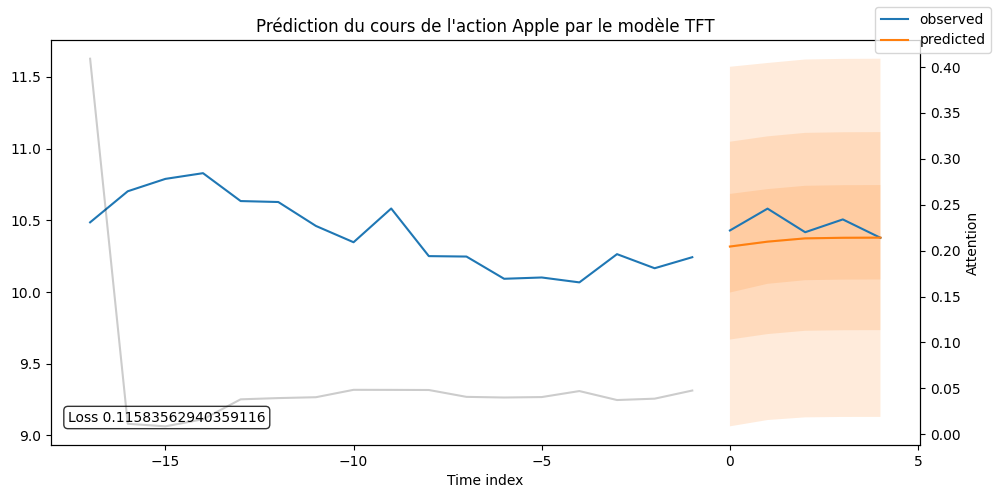

In [ ]:
#for idx in range(10):  # mise en graphique des 10 meilleurs prédictions
# best_tft.plot_prediction(x, raw_predictions, idx=idx, add_loss_to_title=True, plot_attention=False);

import matplotlib.pyplot as plt

# On crée le "cadre" du graphique
fig, ax = plt.subplots(figsize=(10, 5))

# On dessine les prédictions du modèle par-dessus les vraies données
best_tft.plot_prediction(x, raw_predictions, idx=0, add_loss_to_title=True, ax=ax)

# On sauvegarde d'abord la loss générée automatiquement par le modèle
texte_loss = ax.get_title()


ax.set_title("Prédiction du cours de l'action Apple par le modèle TFT")

# On place la loss sauvegardée en bas à gauche avec un petit fond lisible
ax.text(0.02, 0.05, texte_loss,
        transform=ax.transAxes,
        verticalalignment='bottom',
        horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()

### Prévisions contre données

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

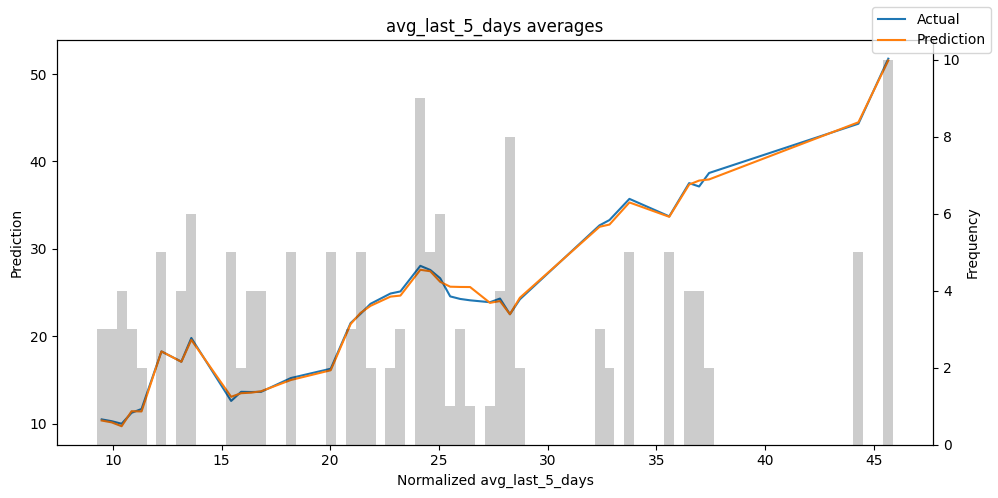

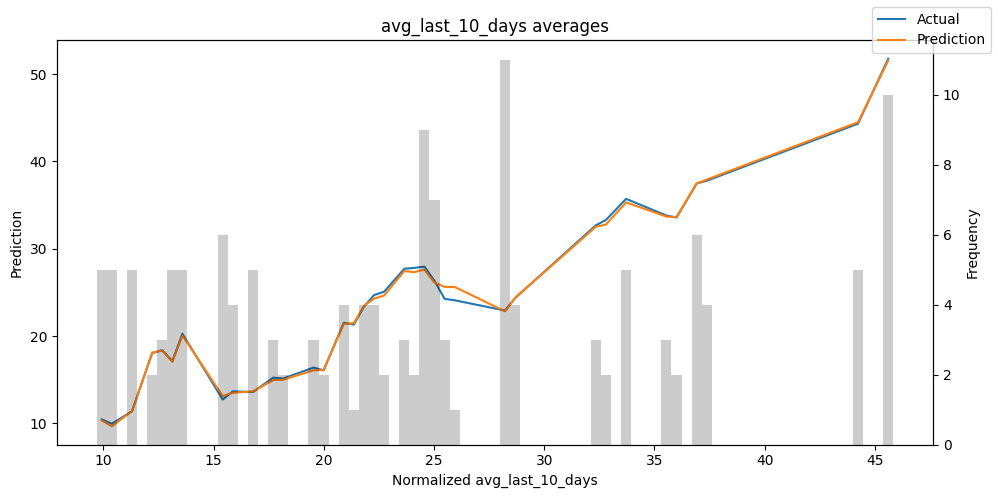

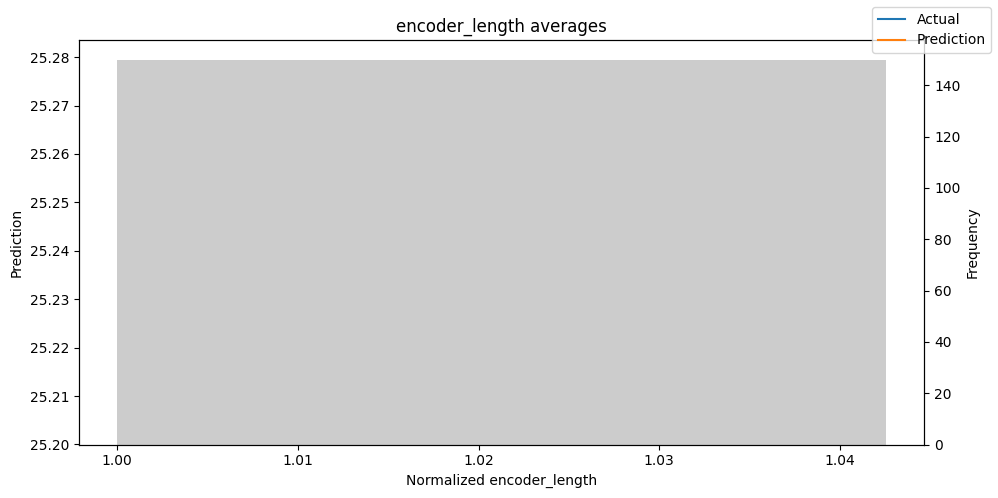

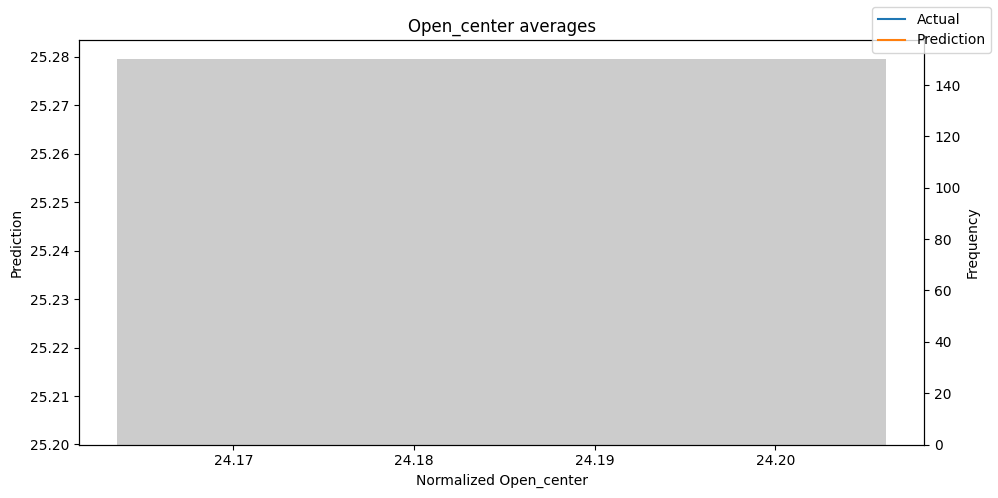

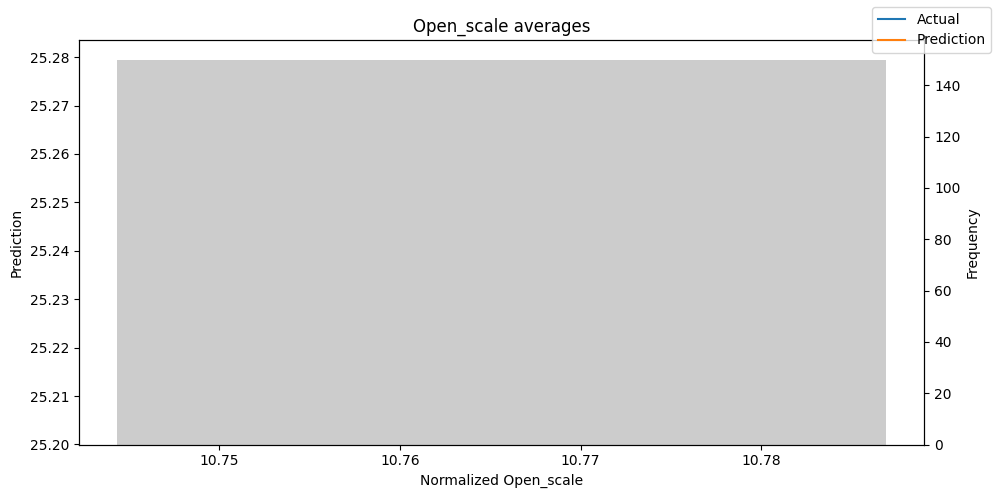

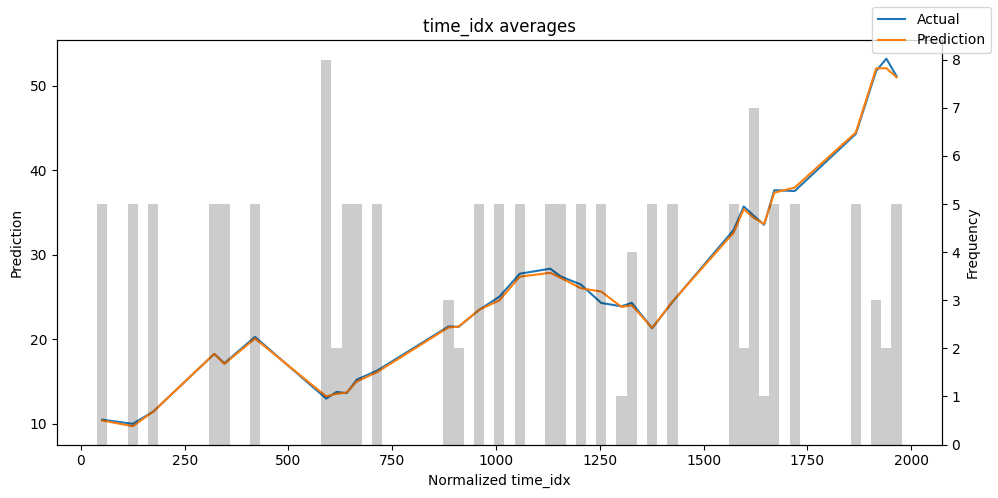

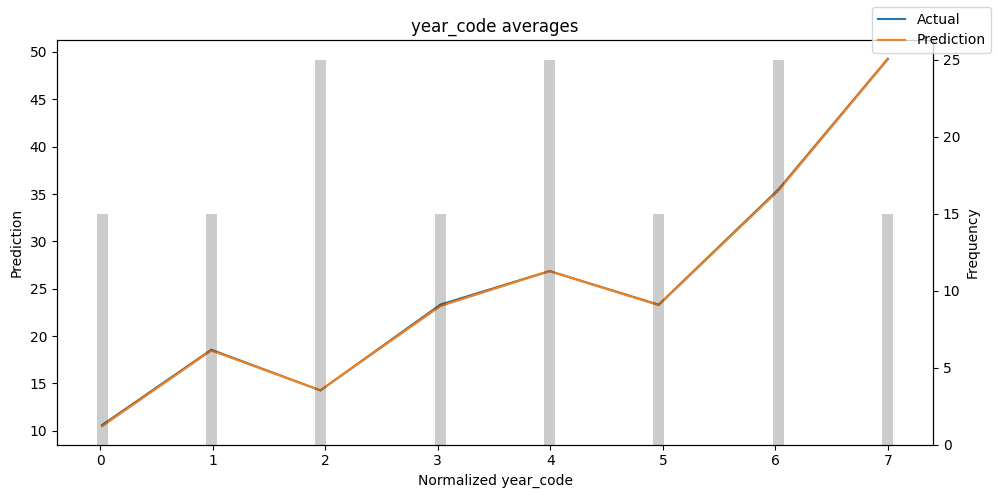

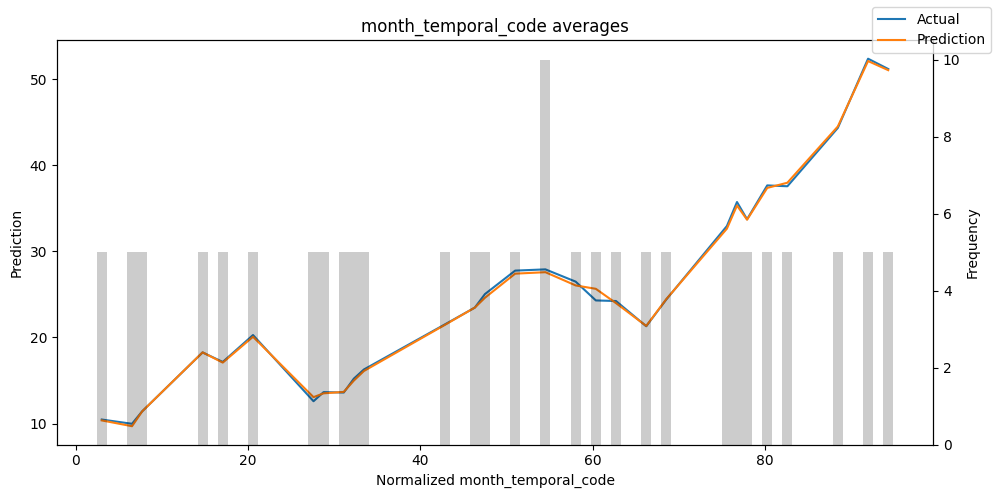

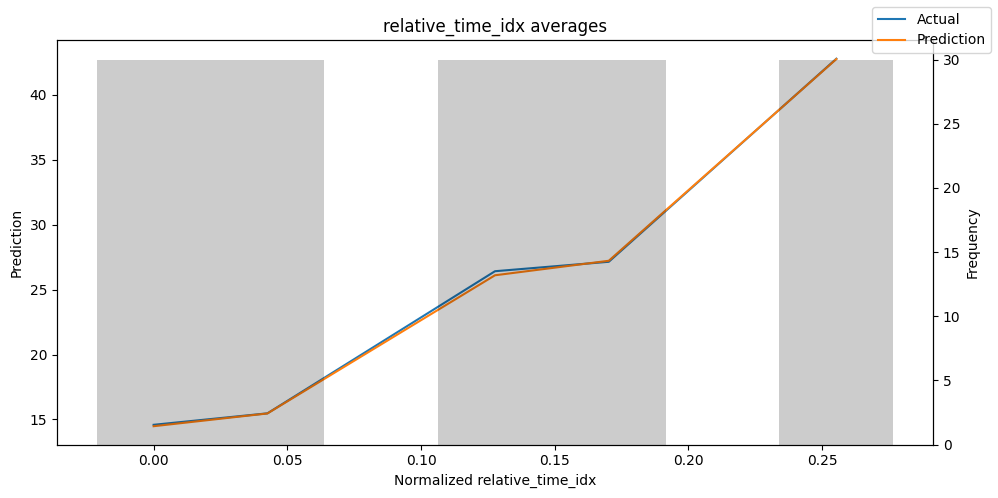

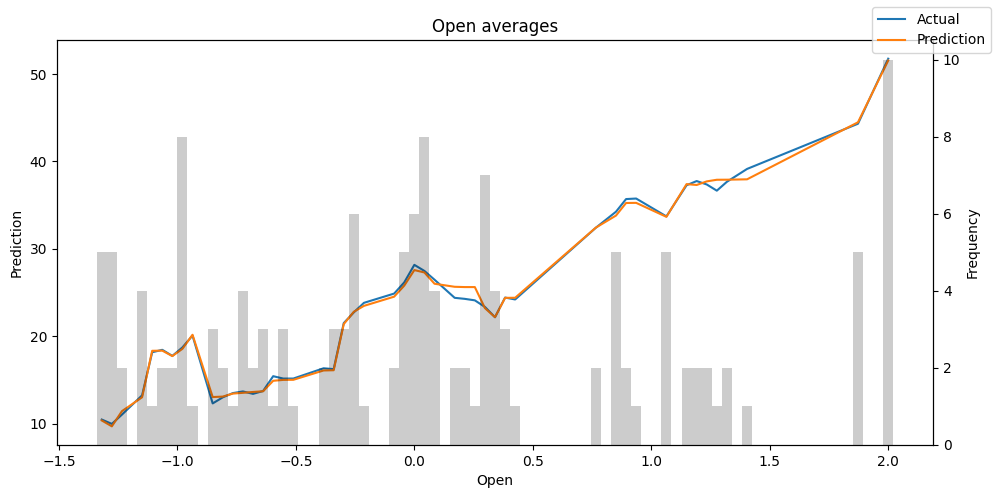

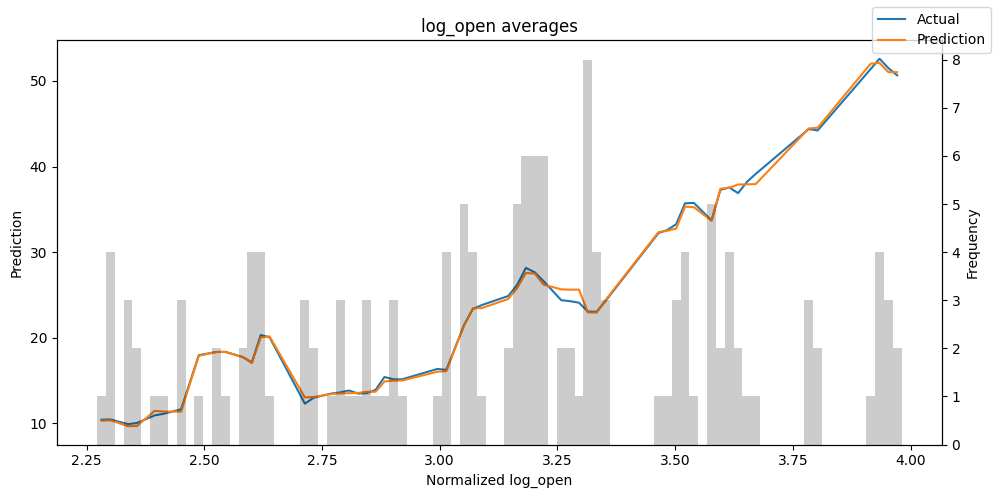

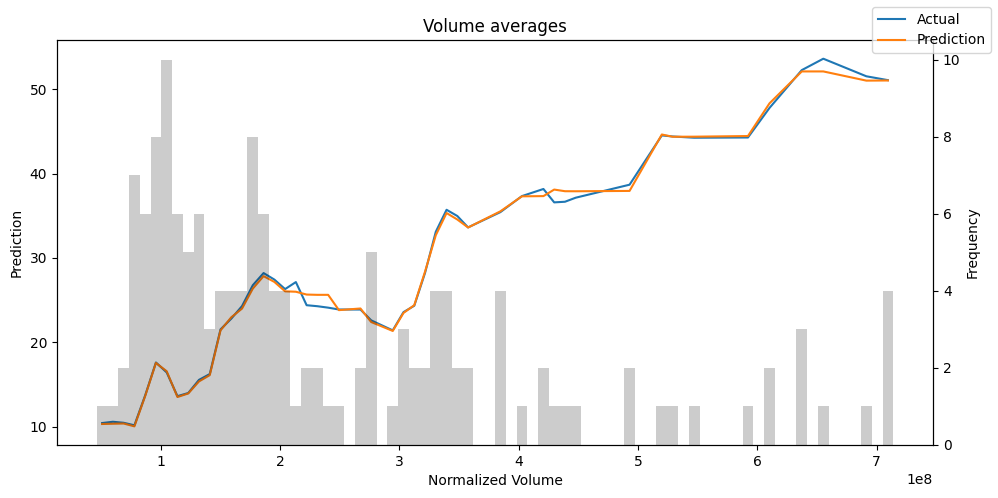

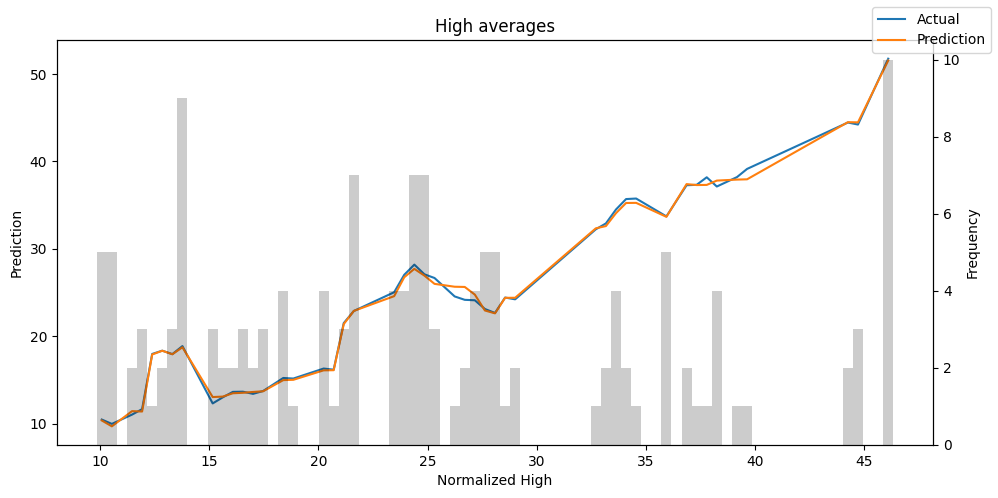

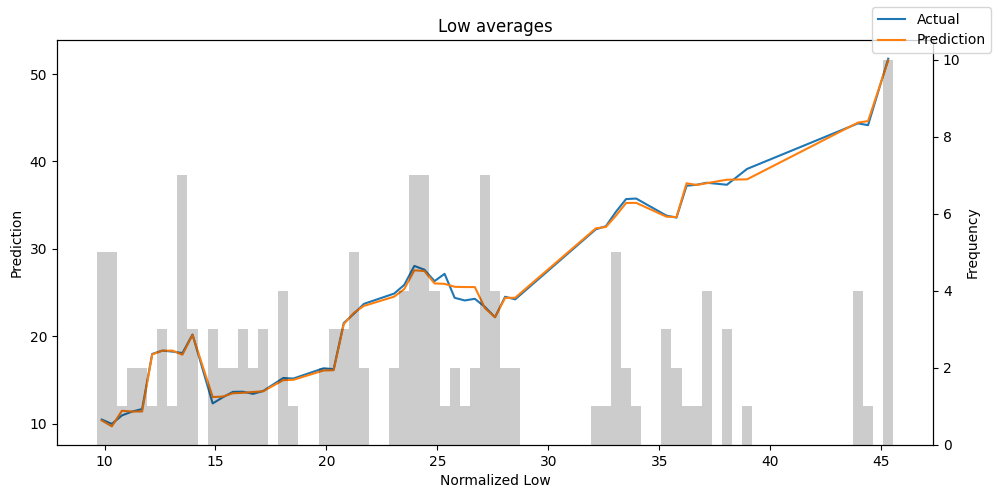

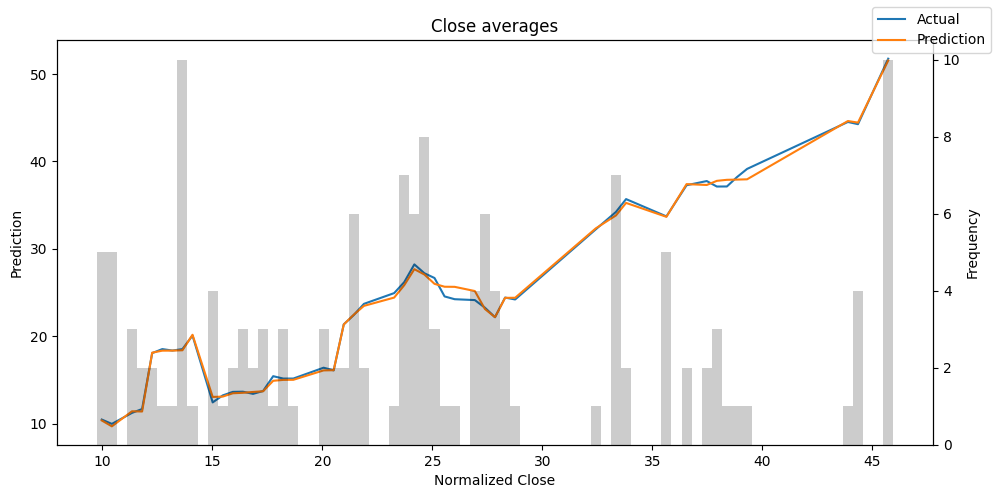

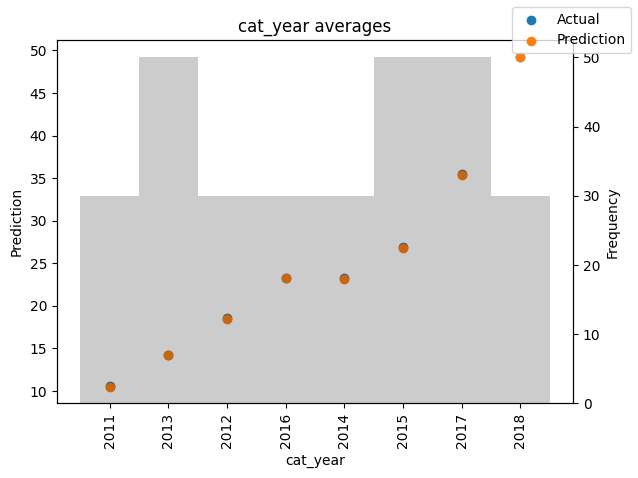

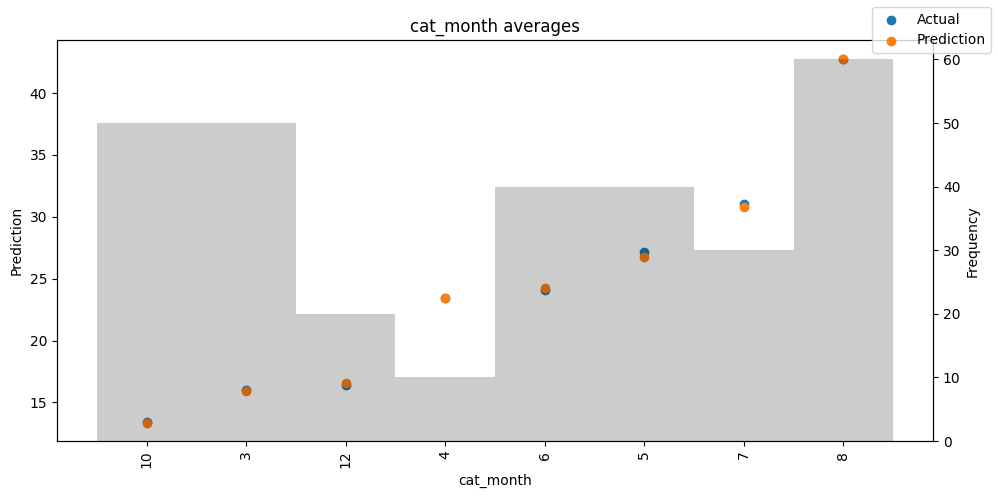

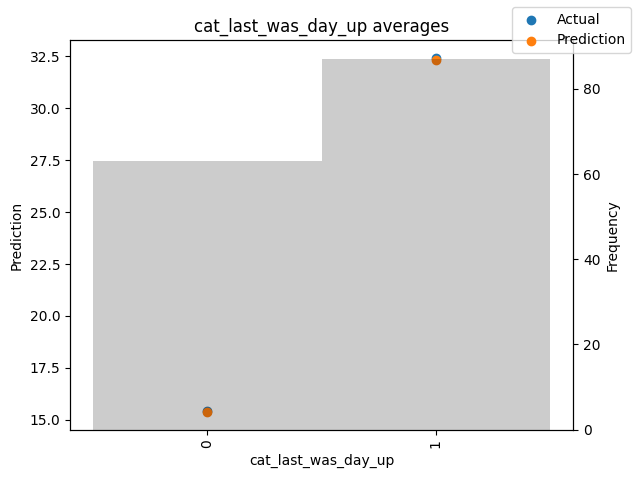

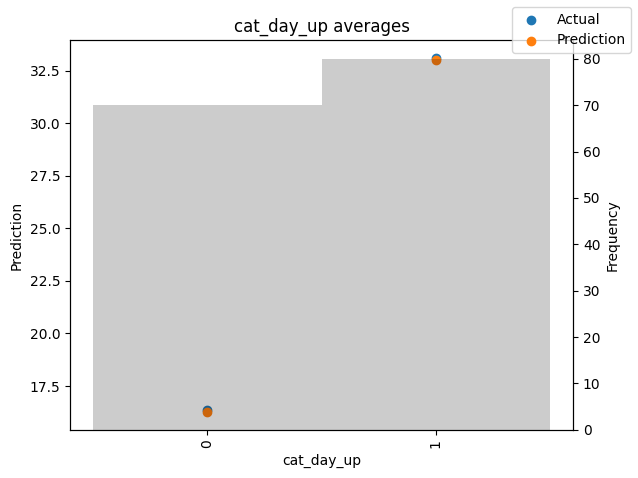

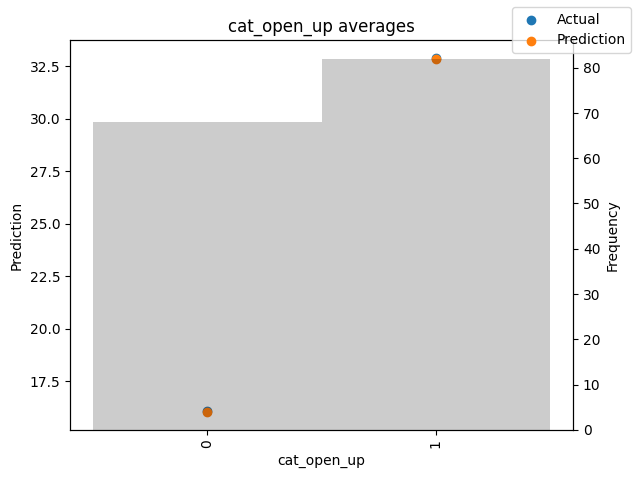

In [ ]:
predictions, x,*le_reste= best_tft.predict(val_dataloader, return_x=True)
predictions_vs_actuals = best_tft.calculate_prediction_actual_by_variable(x, predictions)
best_tft.plot_prediction_actual_by_variable(predictions_vs_actuals);

## Prédictions sur une séléction de données

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

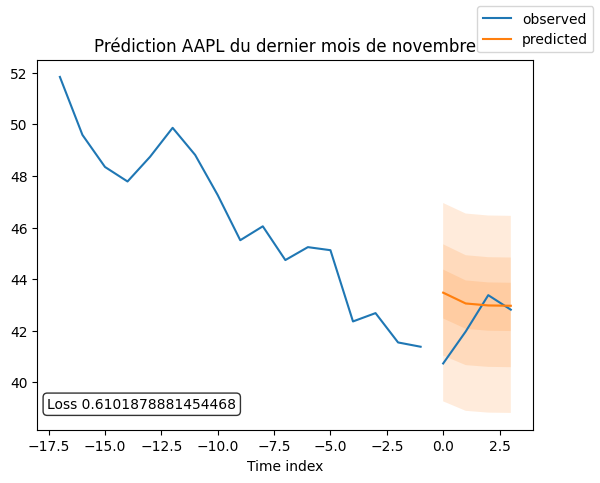

In [ ]:
nbm = max(data.cat_month_temporal_code)
eval1 = nbm - 1 # dernier mois de novembre
eval2 = nbm - 4 # dernier mois d'Août
eval3 = nbm - 7 # dernier mois de mai
# Prédictions de novembre (Quantiles)
best_tft.predict(
    training.filter(lambda x: (x.cat_month_temporal_code == eval1)),
    mode="quantiles",
)

# Representation graphique de novembre (Raw)
raw_prediction, x, *le_reste = best_tft.predict(
    training.filter(lambda x: (x.cat_month_temporal_code == eval1)),
    mode="raw",
    return_x=True,
)

# On capture la figure générée par le modèle
fig = best_tft.plot_prediction(x, raw_prediction, idx=0, add_loss_to_title=True, plot_attention=False)

# On récupère l'axe principal pour manipuler le texte
ax = fig.gca()

# On sauvegarde la loss générée par le modèle
texte_loss = ax.get_title()

# On met votre titre personnalisé en haut
ax.set_title("Prédiction AAPL du dernier mois de novembre")

# On ajoute la loss en bas à gauche (x=0.02, y=0.05) avec un fond blanc
ax.text(0.02, 0.05, texte_loss,
        transform=ax.transAxes,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

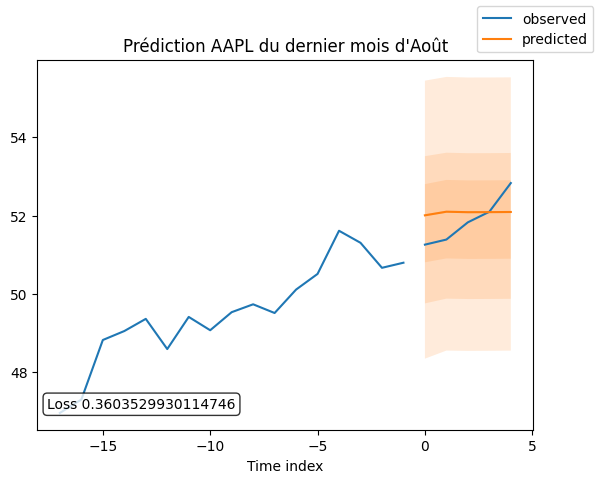

In [ ]:
# Prédictions dernier mois d'Août(Quantiles)
best_tft.predict(
    training.filter(lambda x: (x.cat_month_temporal_code == eval2)),
    mode="quantiles",
)

# Representation graphique d'Août(Raw)
raw_prediction, x, *le_reste = best_tft.predict(
    training.filter(lambda x: (x.cat_month_temporal_code == eval2)),
    mode="raw",
    return_x=True,
)

# On capture la figure générée par le modèle
fig = best_tft.plot_prediction(x, raw_prediction, idx=0, add_loss_to_title=True, plot_attention=False)

# On récupère l'axe principal pour manipuler le texte
ax = fig.gca()

# On sauvegarde la loss générée par le modèle
texte_loss = ax.get_title()

# On met votre titre personnalisé en haut
ax.set_title("Prédiction AAPL du dernier mois d'Août")

# On ajoute la loss en bas à gauche (x=0.02, y=0.05) avec un fond blanc
ax.text(0.02, 0.05, texte_loss,
        transform=ax.transAxes,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

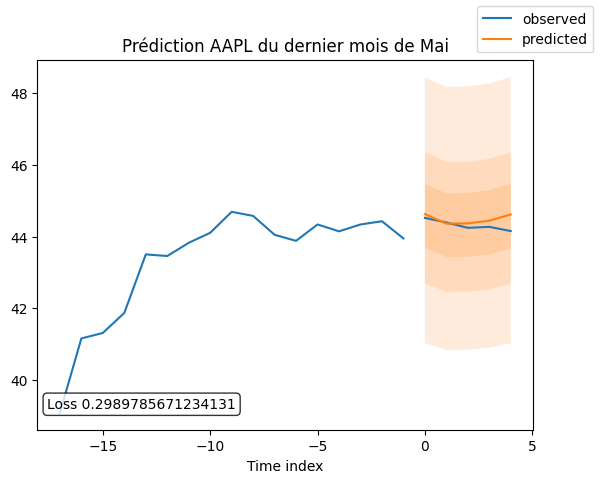

In [ ]:
# Prédictions de Mai (Quantiles)
best_tft.predict(
    training.filter(lambda x: (x.cat_month_temporal_code == eval3)),
    mode="quantiles",
)

# Representation graphique de Mai (Raw)
raw_prediction, x, *le_reste = best_tft.predict(
    training.filter(lambda x: (x.cat_month_temporal_code == eval3)),
    mode="raw",
    return_x=True,
)

# On capture la figure générée par le modèle
fig = best_tft.plot_prediction(x, raw_prediction, idx=0, add_loss_to_title=True, plot_attention=False)

# On récupère l'axe principal pour manipuler le texte
ax = fig.gca()

# On sauvegarde la loss générée par le modèle
texte_loss = ax.get_title()

# On met votre titre personnalisé en haut
ax.set_title("Prédiction AAPL du dernier mois de Mai")

# On ajoute la loss en bas à gauche (x=0.02, y=0.05) avec un fond blanc
ax.text(0.02, 0.05, texte_loss,
        transform=ax.transAxes,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()

## Interprétation du modèle

ENG : The model has inbuilt interpretation capabilities due to how its architecture is build. Let’s see how that looks. We first calculate interpretations with [interpret_output()](https://pytorch-forecasting.readthedocs.io/en/latest/api/pytorch_forecasting.models.temporal_fusion_transformer.TemporalFusionTransformer.html#pytorch_forecasting.models.temporal_fusion_transformer.TemporalFusionTransformer.interpret_output) and plot them subsequently with [plot_interpretation()](https://pytorch-forecasting.readthedocs.io/en/latest/api/pytorch_forecasting.models.temporal_fusion_transformer.TemporalFusionTransformer.html#pytorch_forecasting.models.temporal_fusion_transformer.TemporalFusionTransformer.plot_interpretation).

{'attention': <Figure size 640x480 with 1 Axes>,
 'static_variables': <Figure size 700x400 with 1 Axes>,
 'encoder_variables': <Figure size 700x550 with 1 Axes>,
 'decoder_variables': <Figure size 700x350 with 1 Axes>}

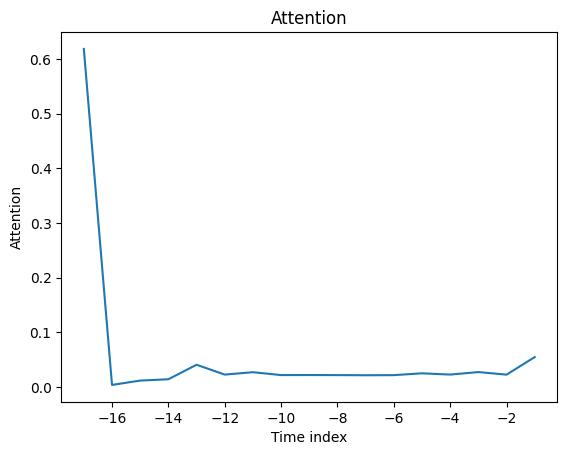

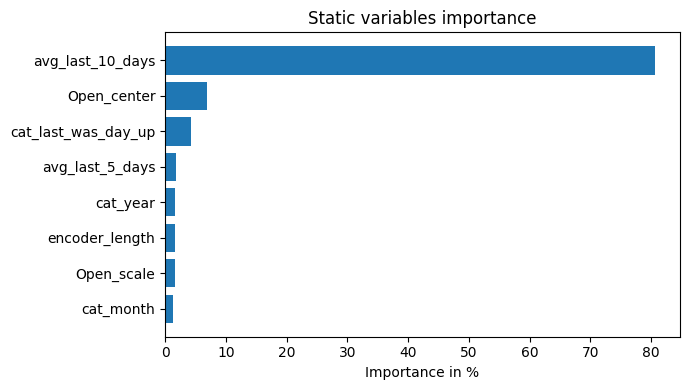

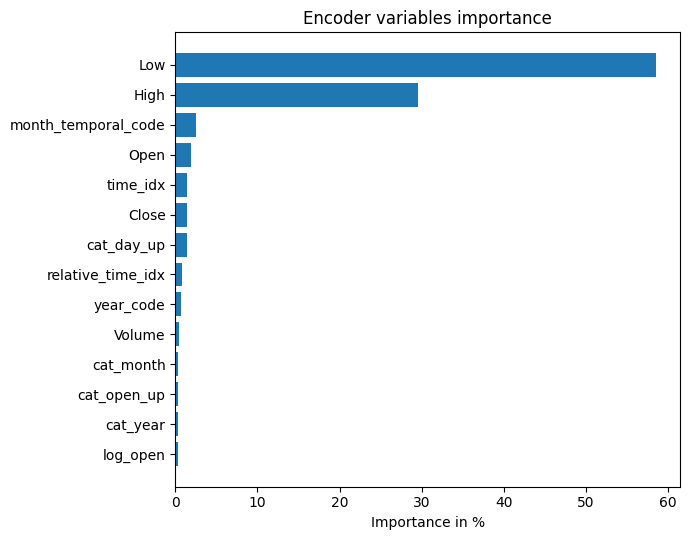

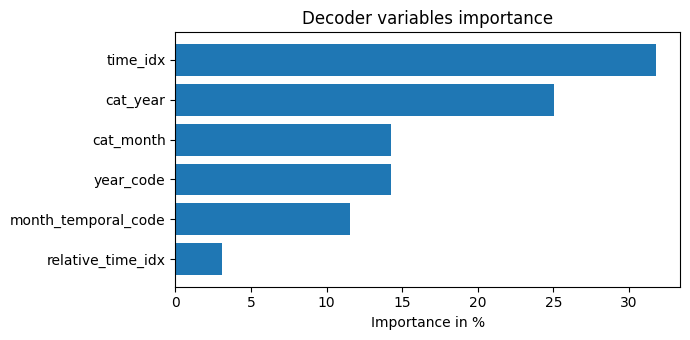

In [ ]:
# Permet d'observer l'attention du modèle et l'importance des variables
interpretation = best_tft.interpret_output(raw_predictions, reduction="sum")
best_tft.plot_interpretation(interpretation)